# Notebook 04 - Coastal Water Mask and Spectral Analysis

## Objective

- This notebook develops a robust coastal water mask from Planet Tanager hyperspectral imagery.

- After isolating water pixels, we investigate the spatial variability of coastal water reflectance to identify regions with differing optical properties that may correspond to sediment-rich water, shallow water, or clearer offshore water.

- The outputs from this notebook form the basis for later clustering and water-quality interpretation.

In [5]:
#1_Import data
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10,8)

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")


In [20]:
#2_Load data
with h5py.File(DATA_PATH, "r") as f:
    cube = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"][:]
    wavelengths = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"].attrs["wavelengths"]
    good = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"].attrs["good_wavelengths"]
    cloud = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask"][:]
cube = cube.astype(np.float32)
cube[cube == -9999] = np.nan
print(cube.shape)
print(cloud.shape)

(426, 671, 763)
(671, 763)


In [21]:
#3_Use good bands
cube = cube[good.astype(bool)]
wavelengths = wavelengths[good.astype(bool)]
print(cube.shape)

(368, 671, 763)


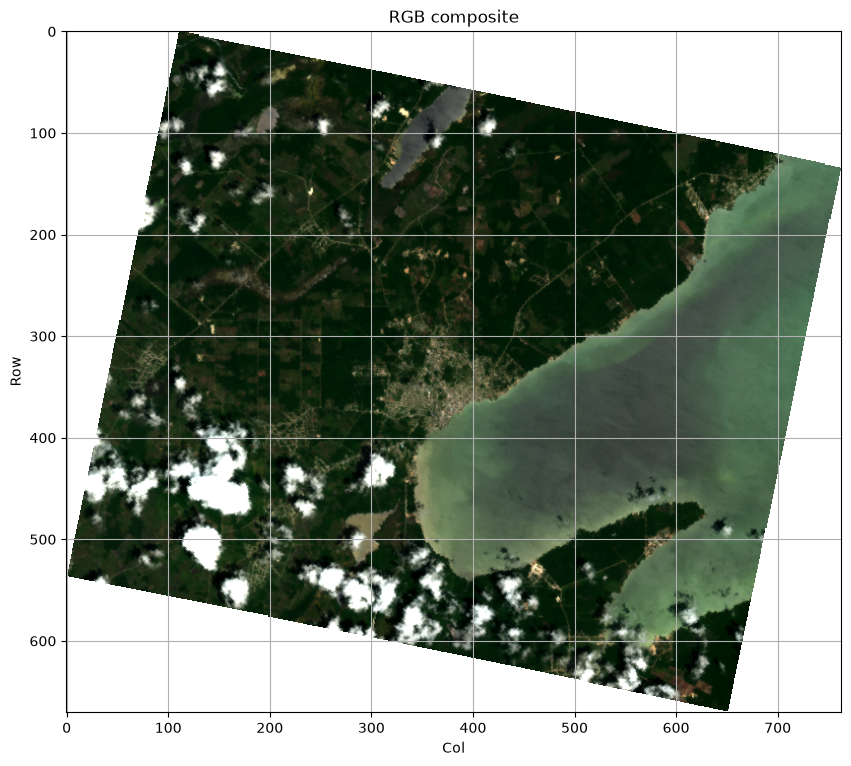

In [30]:
#4_RGB
def find_band(target):
    return np.argmin(np.abs(wavelengths - target))

red = find_band(650)
green = find_band(550)
blue = find_band(470)

def stretch(image, lower=2, upper=98):
    image = image.copy()
    p2 = np.nanpercentile(image, lower)
    p98 = np.nanpercentile(image, upper)
    image = np.clip(image, p2, p98)
    image = (image - p2) / (p98 - p2)
    return image

rgb = np.dstack([cube[red], cube[green], cube[blue]])
rgb = stretch(rgb)

plt.figure(figsize = (10,10))
plt.imshow(rgb)
plt.xlabel("Col")
plt.ylabel("Row")
plt.title("RGB composite")
plt.grid(True)
plt.show()